In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import statistics
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde

# MATH 461 Unit 2 Project

**Group member**
- Ryan Hsiao
- Fanbo Feng
- Davis Li

## Problem description
We set a situation that a person need to find something, like keys, or wallet, in their house, we already know the position of the target object, let the person walk randomly in the house to find it.


<img src="data/Living_Room_Birds-eye-view.png" height="500" width="700">

## Question formulation
*What question(s) would you like to answer about your setup above?*
- what the distribution of the finding time? (under 2 different searching strategy)
    - mean: how long will the person find the item on average.
    - variance: how the finding time spread on its distribution.
    - etc.

## Mathematical model
*Identify variables, parameters, equations. List your assumptions.*

<!--*These steps should probably be done simultaneously, not in order -- as you refine your equations, you will need to update your assumptions, etc. Furthermore, you might want to start with the last point, how to answer your question, and work backwards to determine what variables/parameters you need to do this.*

*Note that **independent variables** are variables that vary no matter what -- usually time, sometimes space. **Dependent variables** are variables which are functions of the independent variables. Usually, you are trying to solve for these. **Parameters** are numbers associated with features of the model, whose values you may need to determine by searching in the literature or by further modelling, but they don't usually vary with the independent variables.*-->

<!-- **Assumptions:**

**Variables** 

**Parameters:**

**Equations:** -->


### Assumptions
- The person have a constant speed
- If the person reach the furniture or the wall of the house, he will reflects off and walk in a random direction.
    - do not go over above or under the furniture
- The position of the item is fixed, will not change over time or due to other reason.
- The person will not stop search until finding the item.
- The person cannot be helped by other people or pet.
- The target item
- Consider the house as a two dimensional plane.

### Constraints
- $t>0$.
- $X, Y \in \text{Room}$ 
- $\theta\sim \text{Unif}(0, 2\pi]$


### Variables & Parameters

|    Symbol     | Description                           |         Type         | Dimensions |
| :-----------: | :---: | :------------------: |    :---:   |
|      $X$      | The horizontal position of the person |  Dependent Variable  |      L     |
|      $Y$      | The vertical position of the person   |  Dependent Variable  |      L     |
|     $W_1$     | The horizontal component of Brownian motion | Random Variable|   -    |
|     $W_2$     | The vertical component of Brownian motion | Random Variable|   -    |
|     $v$  | The speed of the person walking in the house | parameter|    LT^-1  |
|     $\sigma$  | The diffusion speed of the person walking with Brownian motion in the house| parameter | L^2T^-1|
| $\theta$ | The angle we move while reach the boundary. | Random variable | - |
| $t$ | Time | Independent variable | T |
| $\Omega$ | Walkable space | Set | - |

### Equations

**Walkable space:**
- For $\Omega$, we have $\Omega = R_{room} \backslash (R_1 \cup R_2 \cup R_3 \cup C_1)$ for
    - $R_1 = \{(x,y) \in \mathbb{R}^2\mid 0.6 \le x \le 2.4 \ , 5.05 \le y \le 5.5 \}$
    - $R_2 = \{(x,y) \in \mathbb{R}^2\mid 0 \le x \le 3 \ , 3.15 \le y \le 4.05 \}$
    - $R_3 = \{(x,y) \in \mathbb{R}^2\mid 4.9 \le x \le 5.8 \ , 1 \le y \le 4 \}$
    - $C_1 = \{(x,y) \in \mathbb{R}^2\mid (x - 1.25)^2 + (y-1.25)^2 \le 0.75^2 \}$
    - $R_{room} =\{(x,y) \in \mathbb{R}^2\mid 0 \le x \le 7.3 \ , 0 \le y \le 5.5\}$  

**Strategy 1:** (Completely Random)
$$
dX = \sigma dW_1, \quad  dY = \sigma dW_2
$$
The **Wiener process** (or **Brownian motion**) is a continous stochastic process $W(t)$ such that:

1. $W(0) = 0$
2. $W(t + \Delta t) - W(t) \sim \mathcal{N}(0,\Delta t)$ for all $\Delta t$
3. $W(t_2) - W(t_1)$ and $W(t_1) - W(t_0)$ are independent for all $0 \leq t_0 < t_1 < t_2$
4. W is continuous

We approximate the Wiener process $W(t)$ with a discrete stochastic process:

1. Choose $T$ and $N$ for a discretization with timestep $\Delta t = T/N$.
2. Generate $N$ random samples of the standard normal distribution $\eta_k \sim \mathcal{N}(0,1)$ for $k=0,1,\dots,N-1$
3. Generate a random sample of the discretization $W = [W_k]$ using the recursive formula determined by the increment requirement above and $W_0 = 0$:

$$
W(t + \Delta t) - W(t) \sim \mathcal{N}(0,\Delta t)
\hspace{5mm} \rightsquigarrow \hspace{5mm}
W_{k+1} = W_k + \sqrt{\Delta t} \, \eta_k \ , \ \ k=0,1,\dots,N-1
$$

**Strategy 2:** (Robot Vacuum)
$$
dX = v*\cos(\theta)dt \quad dY = v*\sin(\theta)dt
$$
- If $(X_{n+1}, Y_{n+1})\in\Omega$ keep original $\theta$, it will be fine; if $(X_{n+1}, Y_{n+1})\not\in\Omega$, $\theta\sim \text{Unif}(0, 2\pi]$, and let $dX=X_{n+1} - X_n=0$ and $dY=Y_{n+1} - Y_n=0$


## How will you answer your question?
*Explain your approach to studying your model. Identify a mathematical quantity you will evaluate to answer your question.*


1. First non-dimensionlize the two equations.
2. Maybe. Check mean and variance.
3. Implement the code and see the distribution.

We wish to find the distribution and other statistical informations of the time spend to find the item with two strategies listed in the model section above.

## Implementation of the equation

In [2]:
time_s1_p1 = []
time_s1_p2 = []
time_s1_p3 = []
time_s1_p4 = []
time_s2_p1 = []
time_s2_p2 = []
time_s2_p3 = []
time_s2_p4 = []


### Strategy 1 with key point #1

In [37]:
Nr = 5000
nbins = 40
time = np.zeros(Nr)
sig = 13.11
dt = 0.001

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location 
target1 = [0.3, 4.2]
r = 0.3

In [38]:
# Save the first trajectory 
xdata = []
ydata = []

In [39]:
for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)

    # Do random walk 
    while (x-0.3)**2 + (y-4.2)**2 > r**2:
        x1 = x + sig*np.random.randn()*np.sqrt(dt)
        y1 = y + sig*np.random.randn()*np.sqrt(dt)

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1
            y = y1

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t

time_s1_p1 = time

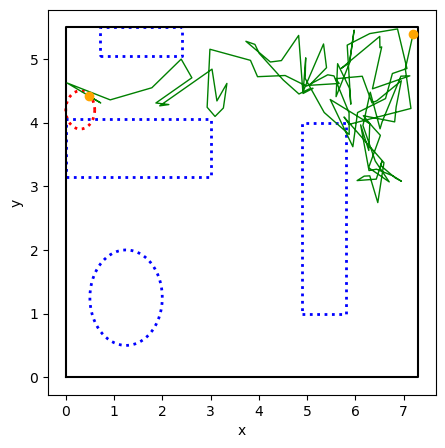

In [40]:
# Plot 
plt.figure(figsize=(5,5))

# Target
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 0.3 + 0.3 * np.cos(theta)
y_circle = 4.2 + 0.3 * np.sin(theta)
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

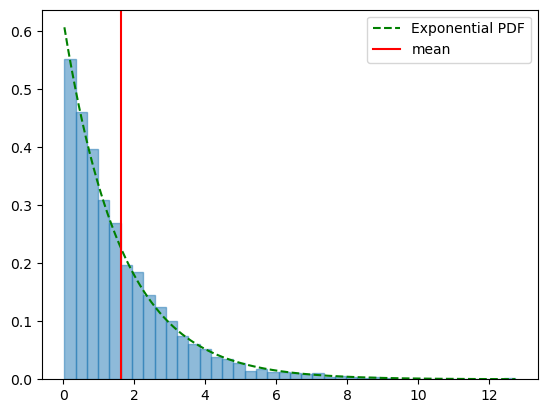

In [41]:
#plot a histogram of times
f_s1_p1 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s1_p1 = np.linspace(min(time_s1_p1), max(time_s1_p1), 500)
mu_s1_p1 = time_s1_p1.mean()
lam_vals_s1_p1 = 1/mu_s1_p1*np.ones(500)
plt.plot(x_vals_s1_p1, f_s1_p1(x_vals_s1_p1, lam_vals_s1_p1), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s1_p1, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p1,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 1 with key point #2

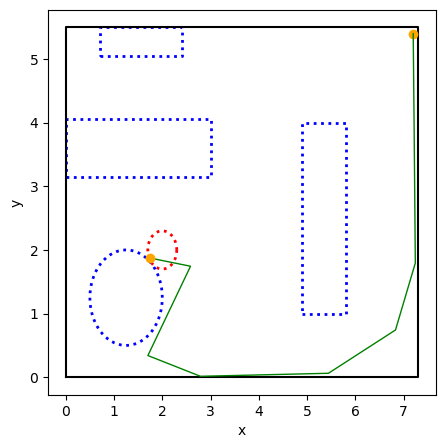

In [8]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [2, 2]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)

    # Do random walk 
    while (x-2)**2 + (y-2)**2 > r**2: # Will change
        x1 = x + sig*np.random.randn()*np.sqrt(dt)
        y1 = y + sig*np.random.randn()*np.sqrt(dt)

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1
            y = y1

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t


# Save time to a new name
time_s1_p2 = time


#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 2 + 0.3 * np.cos(theta) # Change
y_circle = 2 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

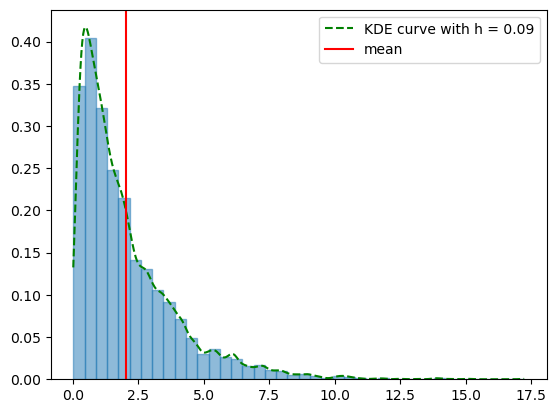

In [9]:
# plot a histogram of times
f_s1_p2 = gaussian_kde(time_s1_p2, bw_method=0.09)
x_vals_s1_p2 = np.linspace(min(time_s1_p2), max(time_s1_p2), 500)
mu_s1_p2 = time_s1_p2.mean()
plt.plot(x_vals_s1_p2, f_s1_p2(x_vals_s1_p2), color='g', linestyle='--', label='KDE curve with h = 0.09')
plt.axvline(mu_s1_p2, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p2,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 1 with key point #3

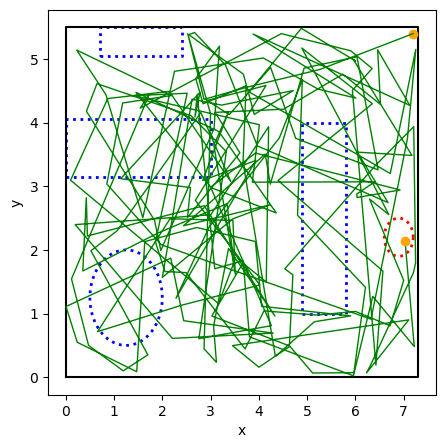

In [10]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [6.9, 2.2]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)

    # Do random walk 
    while (x-6.9)**2 + (y-2.2)**2 > r**2: # Will change
        x1 = x + sig*np.random.randn()*np.sqrt(dt)
        y1 = y + sig*np.random.randn()*np.sqrt(dt)

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1
            y = y1

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t
time_s1_p3 = time
#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 6.9 + 0.3 * np.cos(theta) # Change
y_circle = 2.2 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

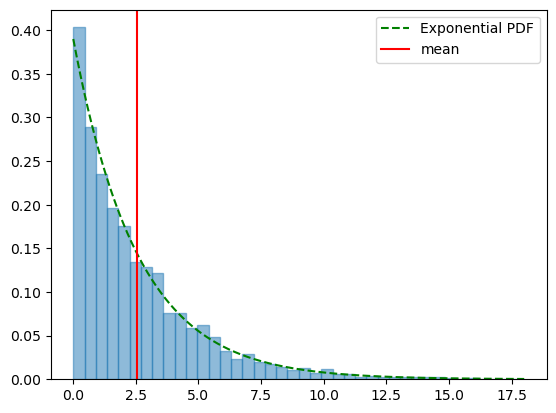

In [11]:
# plot a histogram of times
f_s1_p3 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s1_p3 = np.linspace(min(time_s1_p3), max(time_s1_p3), 500)
mu_s1_p3 = time_s1_p3.mean()
lam_vals_s1_p3 = 1/mu_s1_p3*np.ones(500)
plt.plot(x_vals_s1_p3, f_s1_p3(x_vals_s1_p3, lam_vals_s1_p3), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s1_p3, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p3,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 1 with key point #4

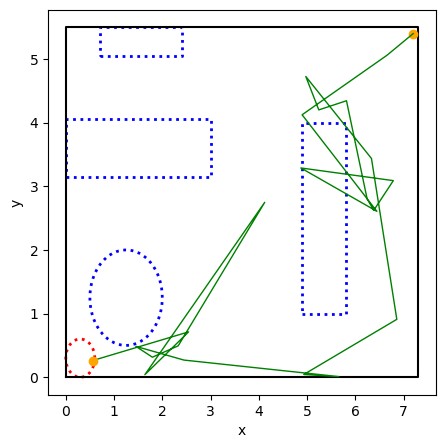

In [12]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [0.3, 0.3]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)

    # Do random walk 
    while (x-0.3)**2 + (y-0.3)**2 > r**2: # Will change
        x1 = x + sig*np.random.randn()*np.sqrt(dt)
        y1 = y + sig*np.random.randn()*np.sqrt(dt)

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1
            y = y1

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t
time_s1_p4 = time
#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 0.3 + 0.3 * np.cos(theta) # Change
y_circle = 0.3 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

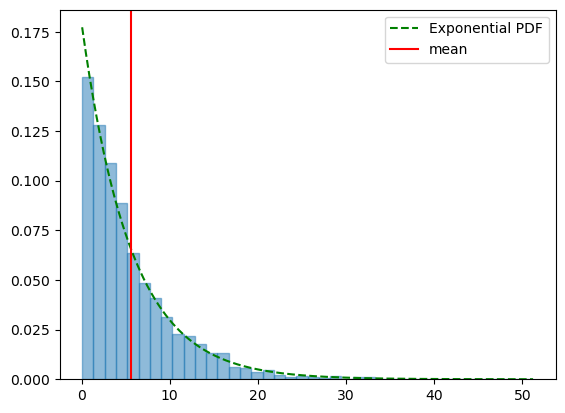

In [31]:
# plot a histogram of times
f_s1_p4 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s1_p4 = np.linspace(min(time_s1_p4), max(time_s1_p4), 500)
mu_s1_p4 = time_s1_p4.mean()
lam_vals_s1_p4 = 1/mu_s1_p4*np.ones(500)
plt.plot(x_vals_s1_p4, f_s1_p4(x_vals_s1_p4, lam_vals_s1_p4), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s1_p4, color='red', linestyle='-', label='mean')
plt.hist(time_s1_p4,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 2 with key point #1

In [14]:
Nr = 5000
nbins = 40
v = 1.31
dt = 0.01

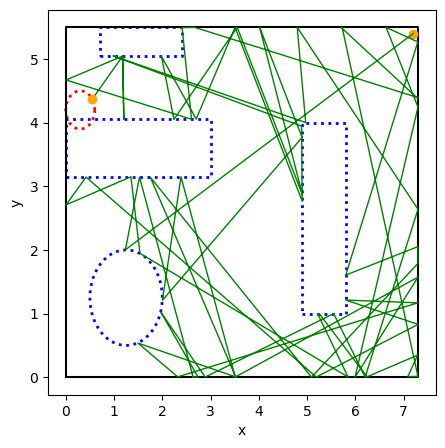

In [15]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [0.3, 4.2]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)
    
    theta = np.random.uniform(0, 2*np.pi)

    # Do random walk 
    while (x-0.3)**2 + (y-4.2)**2 > r**2: # Will change
        x1 = x + v*np.cos(theta)*dt
        y1 = y + v*np.sin(theta)*dt

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1 
            y = y1
        else:
            theta = np.random.uniform(0, 2*np.pi)
            

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t
time_s2_p1 = time
#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 0.3 + 0.3 * np.cos(theta) # Change
y_circle = 4.2 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

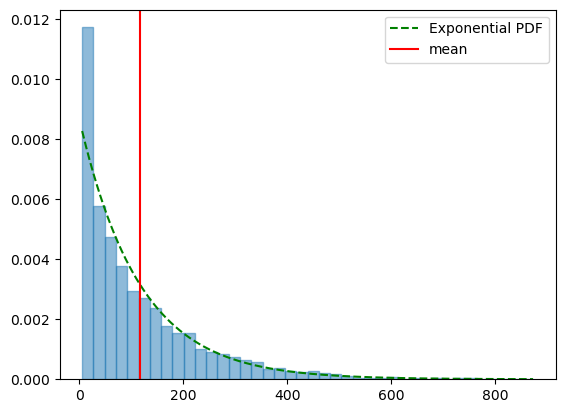

In [16]:
# plot a histogram of times
f_s2_p1 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p1 = np.linspace(min(time_s2_p1), max(time_s2_p1), 500)
mu_s2_p1 = time_s2_p1.mean()
lam_vals_s2_p1 = 1/mu_s2_p1*np.ones(500)
plt.plot(x_vals_s2_p1, f_s2_p1(x_vals_s2_p1, lam_vals_s2_p1), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s2_p1, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p1,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 2 with key point #2

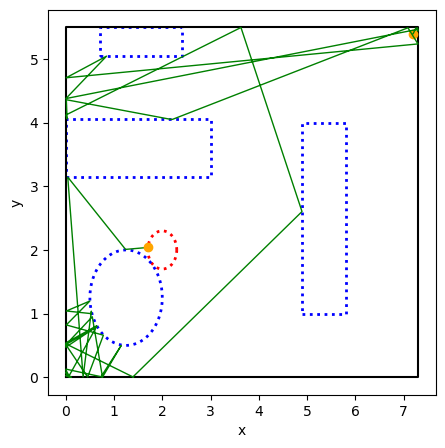

In [17]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [2, 2]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)
    
    theta = np.random.uniform(0, 2*np.pi)

    # Do random walk 
    while (x-2)**2 + (y-2)**2 > r**2: # Will change
        x1 = x + v*np.cos(theta)*dt
        y1 = y + v*np.sin(theta)*dt

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1 
            y = y1
        else:
            theta = np.random.uniform(0, 2*np.pi)
            

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t
time_s2_p2 = time
#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 2 + 0.3 * np.cos(theta) # Change
y_circle = 2 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

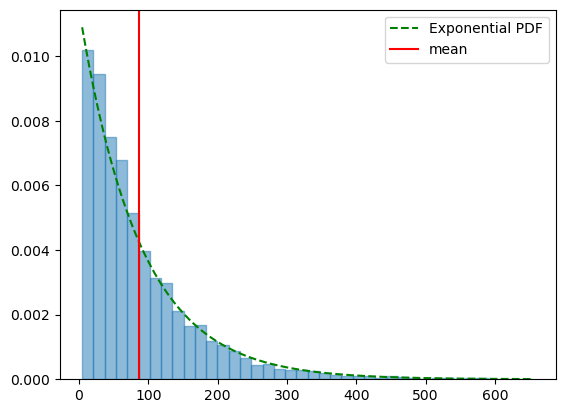

In [18]:
# plot a histogram of times
f_s2_p2 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p2 = np.linspace(min(time_s2_p2), max(time_s2_p2), 500)
mu_s2_p2 = time_s2_p2.mean()
lam_vals_s2_p2 = 1/mu_s2_p2*np.ones(500)
plt.plot(x_vals_s2_p2, f_s2_p2(x_vals_s2_p2, lam_vals_s2_p2), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s2_p2, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p2,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 2 with key point #3

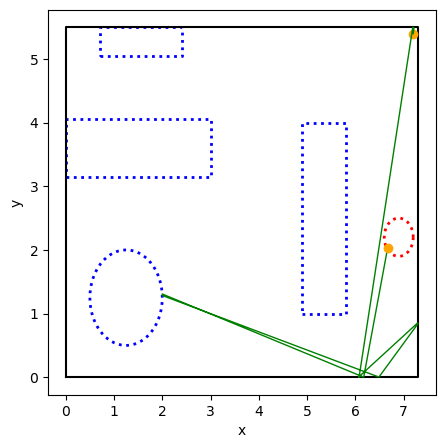

In [19]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [6.9, 2.2]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)
    
    theta = np.random.uniform(0, 2*np.pi)

    # Do random walk 
    while (x-6.9)**2 + (y-2.2)**2 > r**2: # Will change
        x1 = x + v*np.cos(theta)*dt
        y1 = y + v*np.sin(theta)*dt

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1 
            y = y1
        else:
            theta = np.random.uniform(0, 2*np.pi)
            

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t
time_s2_p3 = time
#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 6.9 + 0.3 * np.cos(theta) # Change
y_circle = 2.2 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

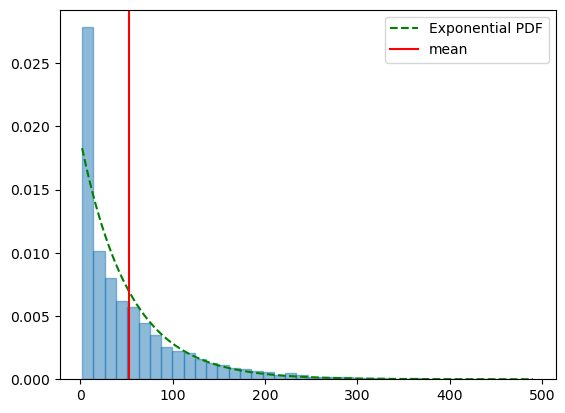

In [20]:
# plot a histogram of times
f_s2_p3 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p3 = np.linspace(min(time_s2_p3), max(time_s2_p3), 500)
mu_s2_p3 = time_s2_p3.mean()
lam_vals_s2_p3 = 1/mu_s2_p3*np.ones(500)
plt.plot(x_vals_s2_p3, f_s2_p3(x_vals_s2_p3, lam_vals_s2_p3), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s2_p3, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p3,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

### Strategy 2 with key point #4

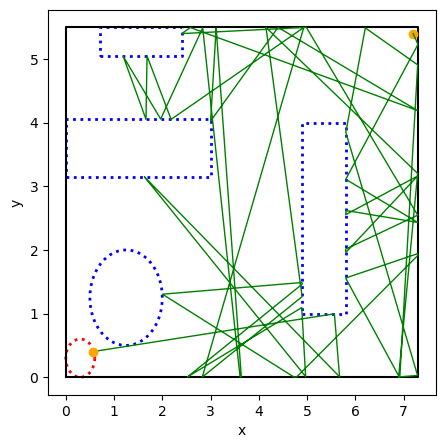

In [21]:
time = np.zeros(Nr)

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

# Wallet location / Will change
target1 = [0.3, 0.3]
r = 0.3

#------------------------------------------------------#

# Save the first trajectory 
xdata = []
ydata = []

#------------------------------------------------------#

for k in range(Nr):
    # Initial position
    x = 7.2
    y = 5.4
    t = 0 # Reset the time 

    # Initialize the starting location 
    if k==1:
        xdata.append(x)
        ydata.append(y)
    
    theta = np.random.uniform(0, 2*np.pi)

    # Do random walk 
    while (x-0.3)**2 + (y-0.3)**2 > r**2: # Will change
        x1 = x + v*np.cos(theta)*dt
        y1 = y + v*np.sin(theta)*dt

        # Conditions 
        Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
        Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
        Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
        Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
        Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

        # Do something while hit the boundary 
        if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
            x = x1 
            y = y1
        else:
            theta = np.random.uniform(0, 2*np.pi)
            

        # Save the path 
        if k==1:
            xdata.append(x)
            ydata.append(y)
        t += dt 

    time[k] = t
time_s2_p4 = time
#------------------------------------------------------#

# Plot 
plt.figure(figsize=(5,5))

# Target / Will change
theta = np.linspace(0, 2*np.pi, 100)
x_circle = 0.3 + 0.3 * np.cos(theta) # Change
y_circle = 0.3 + 0.3 * np.sin(theta) # Change
plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

# C_1
theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 1.25 + 0.75 * np.cos(theta)
y_circle_1 = 1.25 + 0.75 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

# R_1
r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

# R_2
r_2_x = [0, 3.0, 3.0, 0, 0]
r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

# R_3
r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

# R_Room
plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

# Starting point 
plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

# Path
plt.plot(xdata, ydata, color='green', linewidth=1)

# End point
plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

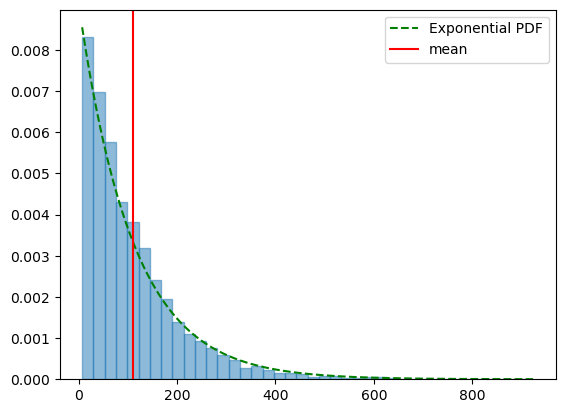

In [22]:
# plot a histogram of times
f_s2_p4 = lambda x, lam: lam*np.exp(-lam*x)
x_vals_s2_p4 = np.linspace(min(time_s2_p4), max(time_s2_p4), 500)
mu_s2_p4 = time_s2_p4.mean()
lam_vals_s2_p4 = 1/mu_s2_p4*np.ones(500)
plt.plot(x_vals_s2_p4, f_s2_p4(x_vals_s2_p4, lam_vals_s2_p4), color='g', linestyle='--', label='Exponential PDF')
plt.axvline(mu_s2_p4, color='red', linestyle='-', label='mean')
plt.hist(time_s2_p4,bins=nbins,density=True,alpha=0.5,edgecolor='C0')
plt.legend()
plt.show()

## Comparing the statistic properties

In [23]:
pd.DataFrame(time_s1_p1).describe()

,0
count,5000.000000
mean,5.424502
std,5.259793
min,0.060000
25%,1.650000
50%,3.850000
75%,7.512500
max,49.590000


In [24]:
pd.DataFrame(time_s1_p2).describe()

,0
count,5000.000000
mean,2.039960
std,1.888095
min,0.020000
25%,0.700000
50%,1.460000
75%,2.810000
max,17.230000


In [25]:
pd.DataFrame(time_s1_p3).describe()

,0
count,5000.000000
mean,2.554642
std,2.575137
min,0.010000
25%,0.690000
50%,1.770000
75%,3.530000
max,18.000000


In [26]:
pd.DataFrame(time_s1_p4).describe()

,0
count,5000.000000
mean,5.572186
std,5.405870
min,0.070000
25%,1.737500
50%,3.930000
75%,7.690000
max,51.200000


In [27]:
pd.DataFrame(time_s2_p1).describe()

,0
count,5000.000000
mean,115.685152
std,122.109576
min,5.120000
25%,26.267500
50%,74.565000
75%,162.775000
max,873.650000


In [28]:
pd.DataFrame(time_s2_p2).describe()

,0
count,5000.000000
mean,87.139148
std,82.850930
min,4.570000
25%,29.535000
50%,61.030000
75%,117.415000
max,654.750000


In [29]:
pd.DataFrame(time_s2_p3).describe()

,0
count,5000.000000
mean,52.431822
std,61.531193
min,2.230000
25%,7.860000
50%,30.705000
75%,73.045000
max,489.900000


In [30]:
pd.DataFrame(time_s2_p4).describe()

,0
count,5000.000000
mean,109.691622
std,100.570619
min,7.100000
25%,37.647500
50%,79.785000
75%,147.727500
max,923.390000
